# Univariate Zeitreihenanalyse — EUR/USD

**Autor:** Alper Bildiren | **Kurs:** Vertiefung Business Analytics (Prof. Dr. Christian Menden)

**Datenquelle:** Federal Reserve St. Louis (FRED) — Series: `DEXUSEU` | **Zeitraum:** 2015–2025

---

Wir folgen der klassischen **Box-Jenkins-Methodik** in sieben Schritten:

1. Visuelle Inspektion
2. Stationaritaetstests (ADF + KPSS)
3. Differenzierung
4. ACF & PACF — Modellidentifikation
5. Modellvergleich (AIC/BIC)
6. Residualdiagnostik
7. Prognose

---
## Schritt 1: Visuelle Inspektion

Vor jeder statistischen Analyse schauen wir uns die Zeitreihe visuell an:

- Gibt es einen **langfristigen Trend**?
- Gibt es Phasen hoeherer oder niedrigerer **Volatilitaet**?
- Gibt es **strukturelle Brueche** (Brexit, COVID-19, EZB-Zinsentscheidungen)?

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from src.utils.data_loader import load_series
from src.utils.preprocessing import adf_test, kpss_test, plot_acf_pacf
from src.models.arima import fit_arima, compare_models, residual_diagnostics, plot_residual_diagnostics

In [2]:
eurusd = load_series("EURUSD=X")
close = eurusd["Close"].dropna()
print(f"Geladen: {len(close)} Beobachtungen ({close.index[0].date()} bis {close.index[-1].date()})")

Geladen: 2748 Beobachtungen (2015-01-02 bis 2025-12-31)


In [3]:
print("=== Datentypen & Struktur ===")
eurusd.info()
print("\n=== Erste Zeilen ===")
display(eurusd.head())
print("\n=== Statistische Kennzahlen ===")
display(eurusd.describe())

=== Datentypen & Struktur ===
<class 'pandas.DataFrame'>
DatetimeIndex: 2748 entries, 2015-01-02 to 2025-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2748 non-null   float64
dtypes: float64(1)
memory usage: 42.9 KB

=== Erste Zeilen ===


,Close
Date,
2015-01-02,1.2015
2015-01-05,1.1918
2015-01-06,1.1936
2015-01-07,1.1820
2015-01-08,1.1811



=== Statistische Kennzahlen ===


,Close
count,2748.000000
mean,1.119921
std,0.051986
min,0.961600
25%,1.084800
50%,1.116850
75%,1.160425
max,1.248800


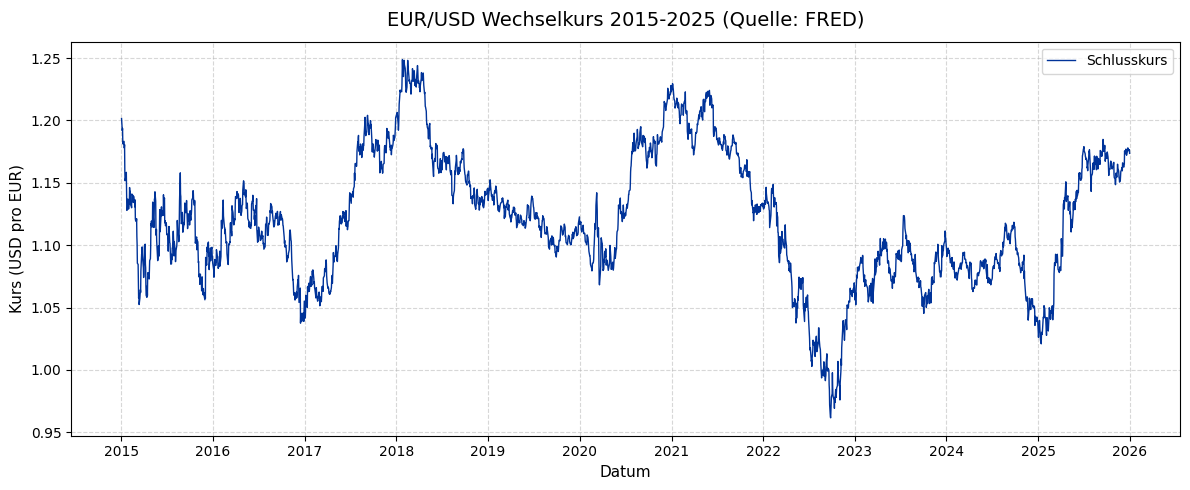

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(close.index, close.values, color="#003399", linewidth=1.0, label="Schlusskurs")
ax.set_title("EUR/USD Wechselkurs 2015-2025 (Quelle: FRED)", fontsize=14, pad=12)
ax.set_xlabel("Datum", fontsize=11)
ax.set_ylabel("Kurs (USD pro EUR)", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

### Erste Beobachtungen

- **Abwaertstrend 2015-2022:** Kurs fiel von ~1.21 auf ~0.96 (unter Paritaet) — getrieben durch EZB-Negativzinspolitik und USD-Staerke nach Ukraine-Krieg und Fed-Zinserhoehungen.
- **Strukturbruch 2022:** Staerkster EUR-Rueckgang seit Jahrzehnten — Kurs fiel erstmals unter 1.00.
- **Erholung 2023-2025:** Mit nachlassender USD-Staerke Erholung auf ~1.05-1.13.
- **Volatilitaetscluster:** Erhoehte Schwankungen 2020 (COVID) und 2022 (Ukraine) sichtbar — Hinweis auf Heteroskedastizitaet.
- **Kein Mean-Reversion:** Die Reihe kehrt nicht zu einem langfristigen Mittelwert zurueck — typisch fuer einen Random-Walk-Prozess.

---
## Schritt 2: Stationaritaetstests (ADF + KPSS)

ARIMA-Modelle setzen **Stationaritaet** voraus. Wir verwenden zwei komplementaere Tests:

| Test | Nullhypothese (H0) | Stationaer wenn... |
|------|-------------------|--------------------|
| **ADF** | Reihe hat Einheitswurzel (nicht stationaer) | p-Wert < 0.05 |
| **KPSS** | Reihe ist stationaer | p-Wert > 0.05 |

Da die Tests aus **entgegengesetzten Richtungen** testen, gibt ihre Kombination staerkere Sicherheit als ein einzelner Test.

In [5]:
result_raw_adf = adf_test(close, title="EUR/USD (Rohdaten)")


ADF-Test: EUR/USD (Rohdaten)
  Test Statistic: -2.8989378703921305
  p-value: 0.04547164817756799
  Lags Used: 0
  Observations: 2747
  Kritischer Wert (1%):  -3.4327
  Kritischer Wert (5%):  -2.8626
  Kritischer Wert (10%):  -2.5673

  Ergebnis: STATIONAER ✓  (p = 0.0455)



In [6]:
result_raw_kpss = kpss_test(close, title="EUR/USD (Rohdaten)")


KPSS-Test: EUR/USD (Rohdaten)
  Test Statistic: 0.8774377952850084
  p-value: 0.01
  Lags Used: 31
  Kritischer Wert (10%):  0.3470
  Kritischer Wert (5%):  0.4630
  Kritischer Wert (2.5%):  0.5740
  Kritischer Wert (1%):  0.7390

  Ergebnis: NICHT STATIONAER ✗  (p = 0.0100)



/Users/alperbildiren/Desktop/Zeitreihenanalyse/MAL-timeseries-forecasting/src/utils/preprocessing.py:98: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression="c", nlags="auto")


### Interpretation der Rohdaten

Der ADF-Test (p = 0.046) liegt knapp unter dem 5%-Schwellenwert — ein Grenzfall. Der KPSS-Test widerspricht klar: p = 0.01, die Reihe ist **nicht stationaer**. Bei Wechselkursen ist der KPSS-Test hier zuverlaessiger, da er sensitiver auf langfristige Trends reagiert. **Fazit: Differenzierung notwendig.**

---
## Schritt 3: Differenzierung

Wir bilden die **erste Differenz** (d=1) und testen erneut:

$$y'_t = y_t - y_{t-1}$$

Statt des absoluten Kurses betrachten wir die **taegliche Kursveraenderung**.

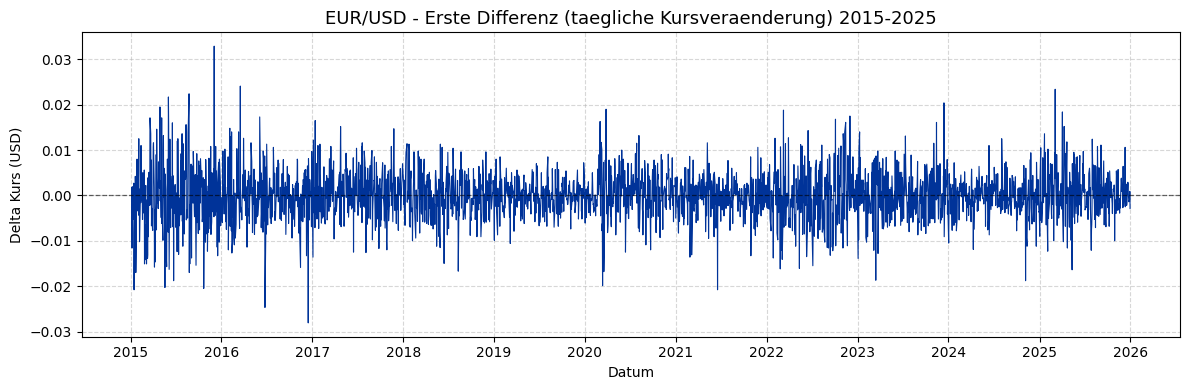

In [7]:
close_diff = close.diff().dropna()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(close_diff.index, close_diff.values, color="#003399", linewidth=0.8)
ax.axhline(0, color="black", linewidth=0.9, linestyle="--", alpha=0.6)
ax.set_title("EUR/USD - Erste Differenz (taegliche Kursveraenderung) 2015-2025", fontsize=13)
ax.set_xlabel("Datum")
ax.set_ylabel("Delta Kurs (USD)")
ax.grid(True, linestyle="--", alpha=0.5)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

In [8]:
result_diff_adf = adf_test(close_diff, title="EUR/USD (1. Differenz)")


ADF-Test: EUR/USD (1. Differenz)
  Test Statistic: -18.301021237305967
  p-value: 2.2865842044034483e-30
  Lags Used: 9
  Observations: 2737
  Kritischer Wert (1%):  -3.4327
  Kritischer Wert (5%):  -2.8626
  Kritischer Wert (10%):  -2.5673

  Ergebnis: STATIONAER ✓  (p = 0.0000)



In [9]:
result_diff_kpss = kpss_test(close_diff, title="EUR/USD (1. Differenz)")


KPSS-Test: EUR/USD (1. Differenz)
  Test Statistic: 0.08906127150433656
  p-value: 0.1
  Lags Used: 6
  Kritischer Wert (10%):  0.3470
  Kritischer Wert (5%):  0.4630
  Kritischer Wert (2.5%):  0.5740
  Kritischer Wert (1%):  0.7390

  Ergebnis: STATIONAER ✓  (p = 0.1000)



/Users/alperbildiren/Desktop/Zeitreihenanalyse/MAL-timeseries-forecasting/src/utils/preprocessing.py:98: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression="c", nlags="auto")


### Interpretation

| Test | Rohdaten | 1. Differenz | Fazit |
|------|----------|--------------|-------|
| ADF  | p = 0.046 (Grenzfall) | p ≈ 0.000 | Stationaer ✓ |
| KPSS | p = 0.010 (nicht stationaer) | p = 0.100 | Stationaer ✓ |

Nach der ersten Differenzierung bestaetigen **beide Tests** Stationaritaet. Der ARIMA-Parameter **d = 1** ist damit festgelegt.

Die Volatilitaetscluster (2020, 2022) im Differenzenplot sind sichtbar — das ist ein bekanntes ARCH/GARCH-Phaenomen bei Wechselkursen und liegt ausserhalb des ARIMA-Rahmens.

---
## Schritt 4: ACF & PACF — Modellidentifikation

Wir analysieren die differenzierte Reihe auf serielle Abhaengigkeiten:

| Funktion | Gibt Hinweis auf |
|----------|------------------|
| **ACF** | MA-Ordnung (q) |
| **PACF** | AR-Ordnung (p) |

Lags **ausserhalb** des blauen Konfidenzbands (95%) sind statistisch signifikant.

**Erwartung:** Bei effizienten Devisenmaerkten erwarten wir kaum signifikante Lags (Efficient Market Hypothesis, Fama 1970).

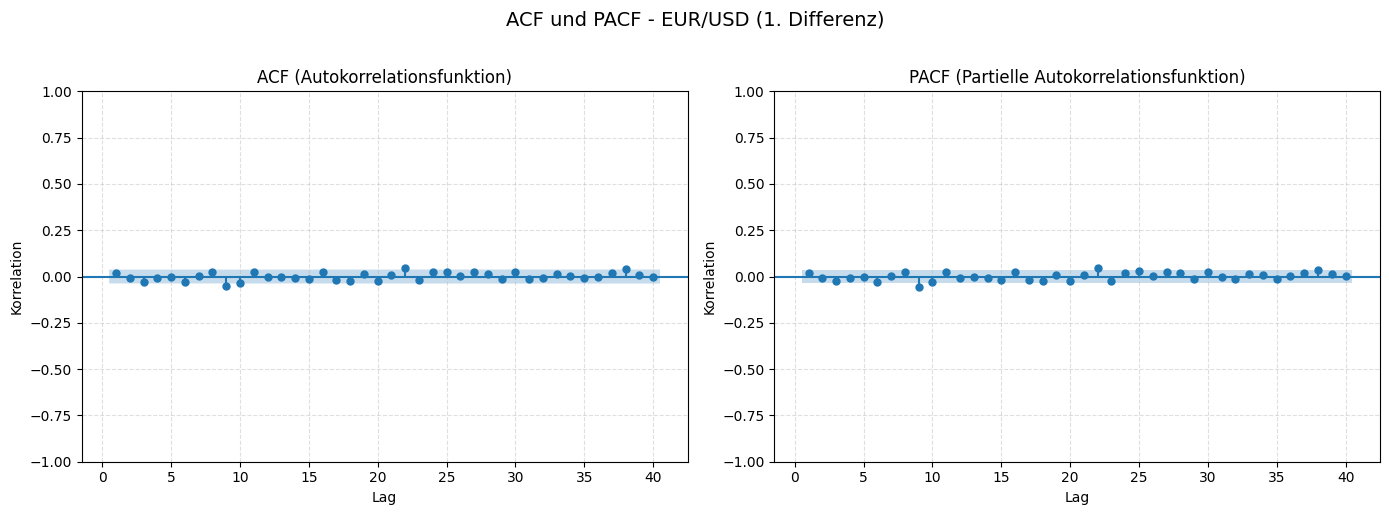

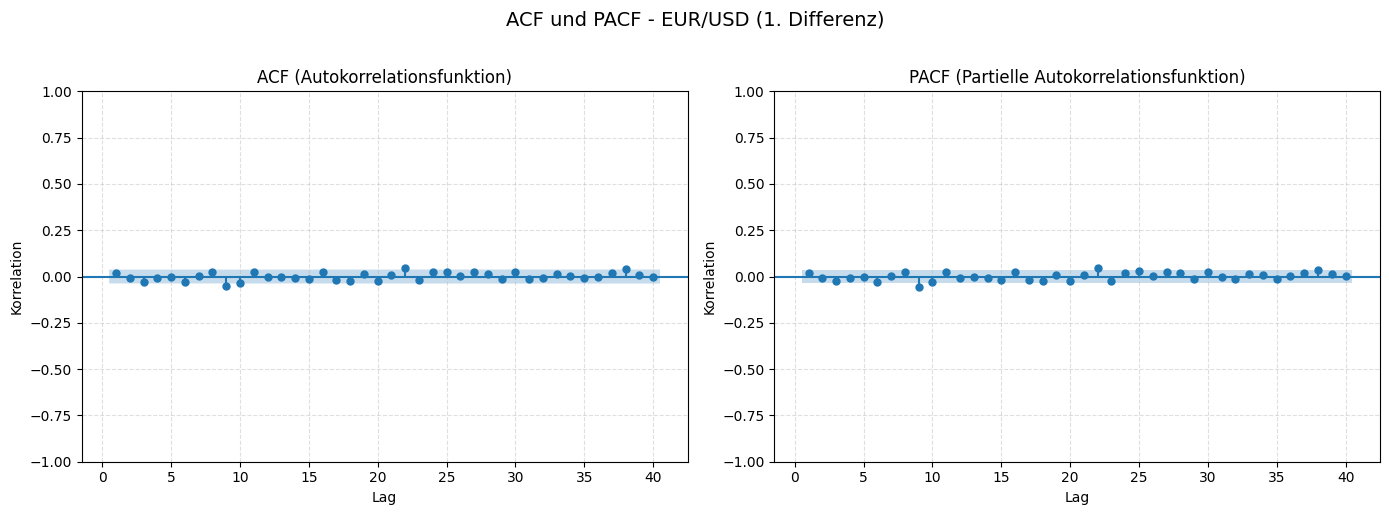

In [10]:
plot_acf_pacf(close_diff, lags=40, title="ACF und PACF - EUR/USD (1. Differenz)")

### Interpretation

ACF und PACF zeigen **keine signifikanten Lags** ausserhalb des Konfidenzbands. Das ist das klassische Muster eines Random-Walk-Prozesses und bestaetigt die Markteffizienz-Hypothese fuer den EUR/USD-Wechselkurs.

Wir testen folgende Kandidaten:

| Modell | Begruendung |
|--------|-------------|
| **ARIMA(0,1,0)** | Random Walk — theoretischer Benchmark |
| **ARIMA(1,1,0)** | AR(1) — falls kurzfristige Persistenz |
| **ARIMA(0,1,1)** | MA(1) — falls Schocks nachwirken |
| **ARIMA(1,1,1)** | ARMA(1,1) — kombiniertes Modell |

---
## Schritt 5: Modellvergleich (AIC/BIC)

Wir passen alle Kandidaten an und vergleichen mit **AIC** und **BIC**:

- Niedrigerer Wert = besseres Modell
- **BIC** bestraft Extraparameter staerker (bei n=2748 besonders relevant)
- Koeffizienten mit p > 0.05 sind statistisch nicht signifikant

In [11]:
candidates = [(0,1,0), (1,1,0), (0,1,1), (1,1,1)]
results = compare_models(close, candidates)
display(results[["model","AIC","BIC","log_likelihood","n_params","converged"]])

,model,AIC,BIC,log_likelihood,n_params,converged
0,"ARIMA(0, 1, 0)",-20789.42,-20783.50,10395.71,2,True
1,"ARIMA(1, 1, 0)",-20788.60,-20776.77,10396.30,3,False
2,"ARIMA(0, 1, 1)",-20780.19,-20768.35,10392.09,3,False
3,"ARIMA(1, 1, 1)",-20778.12,-20760.37,10392.06,4,True


### Methodische Entscheidung

**ARIMA(0,1,0)** gewinnt nach AIC und BIC — der **Random Walk** ist das beste Modell fuer EUR/USD. Das ist kein ueberraschendes Ergebnis:

- Die Efficient Market Hypothesis (Fama, 1970) besagt, dass Wechselkurse alle verfuegbaren Informationen einpreisen
- Empirische Studien zeigen konsistent, dass einfache Random-Walk-Modelle bei kurzfristigen Wechselkursprognosen oft besser abschneiden als komplexere Modelle

Wir verwenden **ARIMA(0,1,1)** als Vergleichsmodell, um zu zeigen, dass der Mehraufwand keine echte Verbesserung bringt.

In [12]:
# Hauptmodell: Random Walk — AIC/BIC Sieger
main_model      = fit_arima(close, order=(0, 1, 0))
# Vergleichsmodell: MA(1) — zum Benchmark-Vergleich
benchmark_model = fit_arima(close, order=(0, 1, 1))

print("=" * 60)
print("Hauptmodell: ARIMA(0,1,0) — Random Walk (AIC/BIC Sieger)")
print("=" * 60)
print(main_model.summary())
print()
print("=" * 60)
print("Vergleichsmodell: ARIMA(0,1,1)")
print("=" * 60)
print(benchmark_model.summary())

Hauptmodell: ARIMA(0,1,0) — Random Walk (AIC/BIC Sieger)
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2748
Model:               SARIMAX(0, 1, 0)   Log Likelihood               10395.708
Date:                Sun, 10 May 2026   AIC                         -20789.417
Time:                        20:28:11   BIC                         -20783.499
Sample:                             0   HQIC                        -20787.278
                               - 2748                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      3.015e-05   5.74e-07     52.488      0.000     2.9e-05    3.13e-05
Ljung-Box (L1) (Q):                   1.21   Jarque-Bera (JB):            

---
## Schritt 6: Residualdiagnostik

Ein gut spezifiziertes Modell hinterlaesst **weisse Residuen**:

| Test / Plot | Was wir pruefen | Erwartetes Ergebnis |
|-------------|-----------------|---------------------|
| Zeitplot | Kein Trend, keine Cluster | Zufaellig um null |
| Histogramm + Normalverteilung | Glockenform? | Annaehernd symmetrisch |
| QQ-Plot | Punkte auf der Diagonale? | Nahe der Linie |
| ACF der Residuen | Keine Autokorrelation | Alle Lags im Konfidenzband |
| **Ljung-Box-Test** | Formale Pruefung | **p > 0.05** |
| Jarque-Bera-Test | Normalitaet | p < 0.05 erwartet (Heavy Tails) |

### 6.1 Hauptmodell: ARIMA(0,1,0) — Random Walk

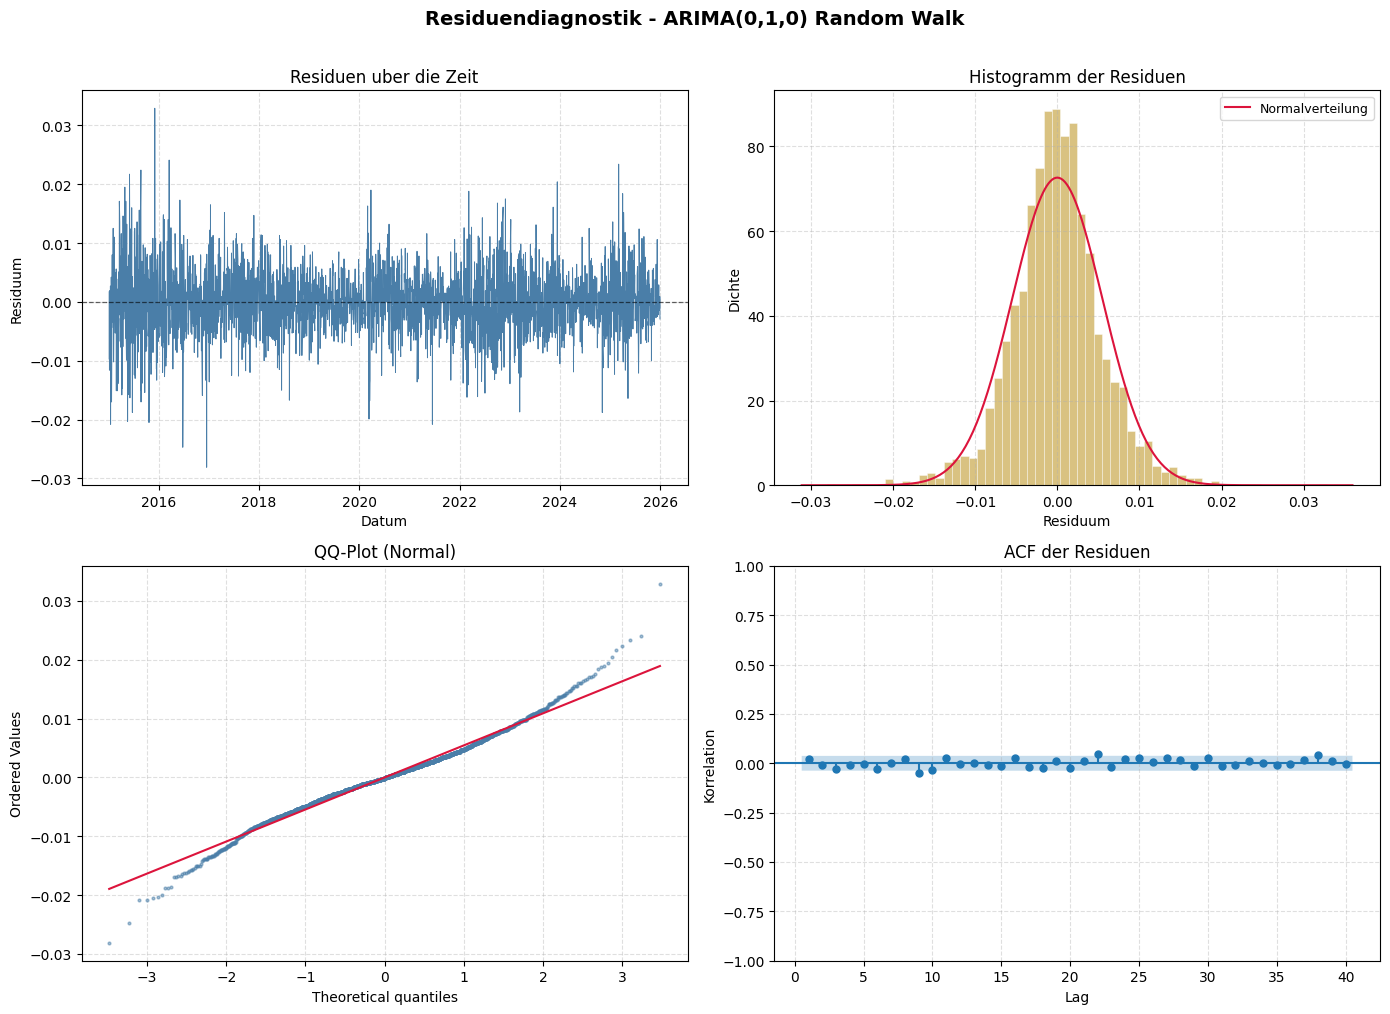

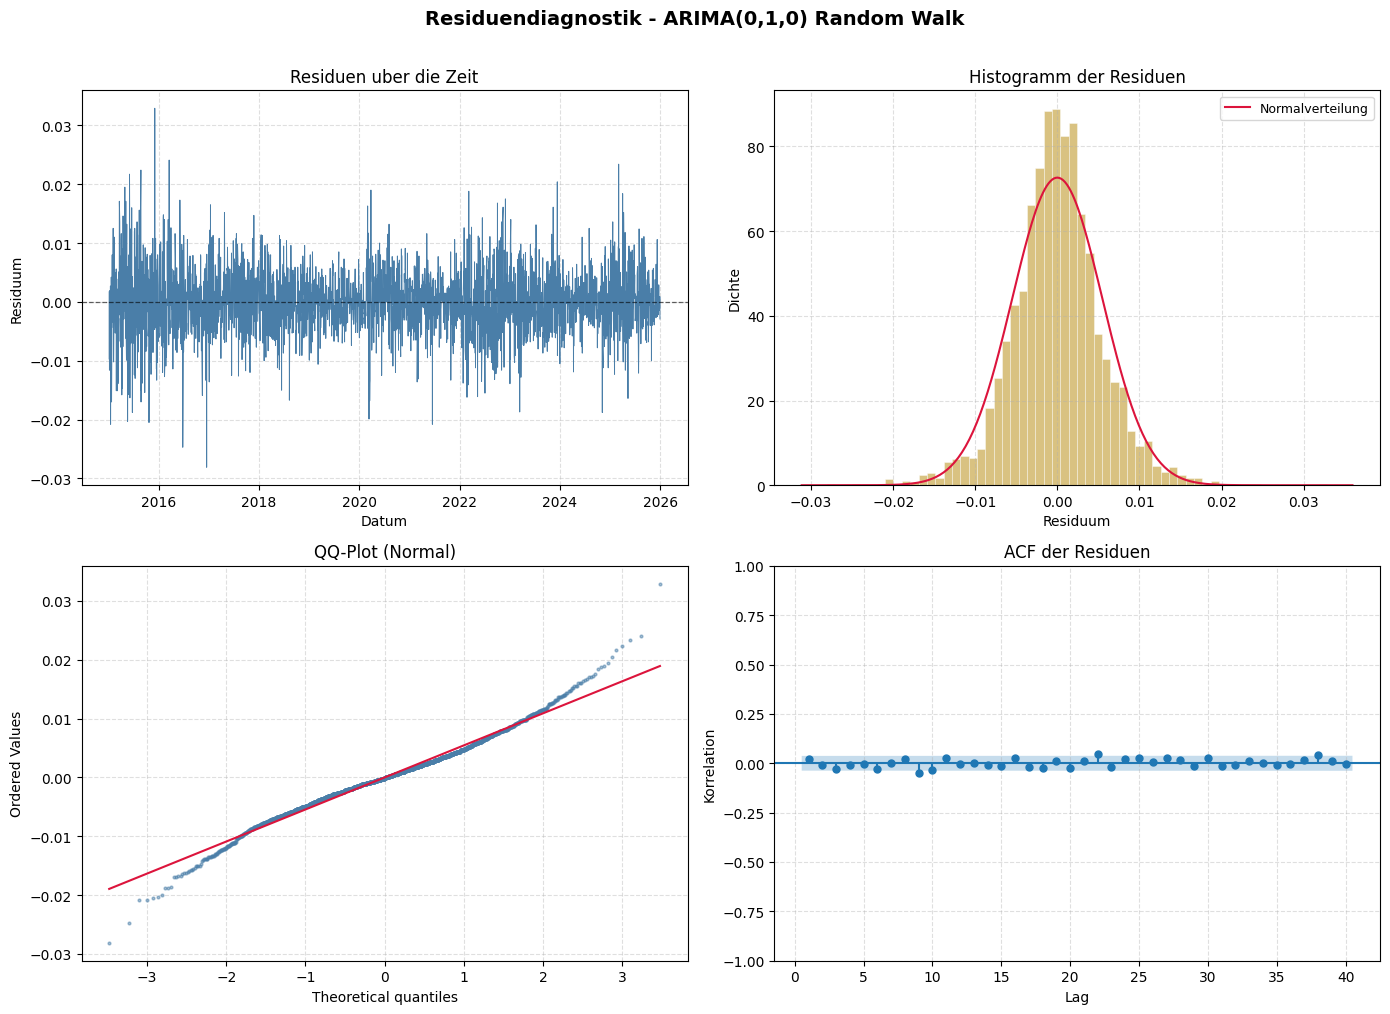

In [13]:
plot_residual_diagnostics(main_model, title="Residuendiagnostik - ARIMA(0,1,0) Random Walk")

In [14]:
diag_main = residual_diagnostics(main_model, lags=[10, 20])


Ljung-Box-Test (H0: keine Autokorrelation)
  Lag 10:  Q =  18.1552,  p = 0.0524  (nicht signifikant ✓)
  Lag 20:  Q =  27.1633,  p = 0.1307  (nicht signifikant ✓)

Jarque-Bera-Test (H0: Normalverteilung)
  JB-Statistik : 463.3362
  p-Wert       : 0.0000  → H0 ABGELEHNT (Heavy Tails erwartet)

Deskriptive Statistiken der Residuen
  Mittelwert        :    -0.0000
  Standardabweichung:     0.0055
  Schiefe (Skew)    :     0.0668
  Excess Kurtosis   :     2.0075  (Normalverteilung = 0)



### 6.2 Vergleichsmodell: ARIMA(0,1,1)

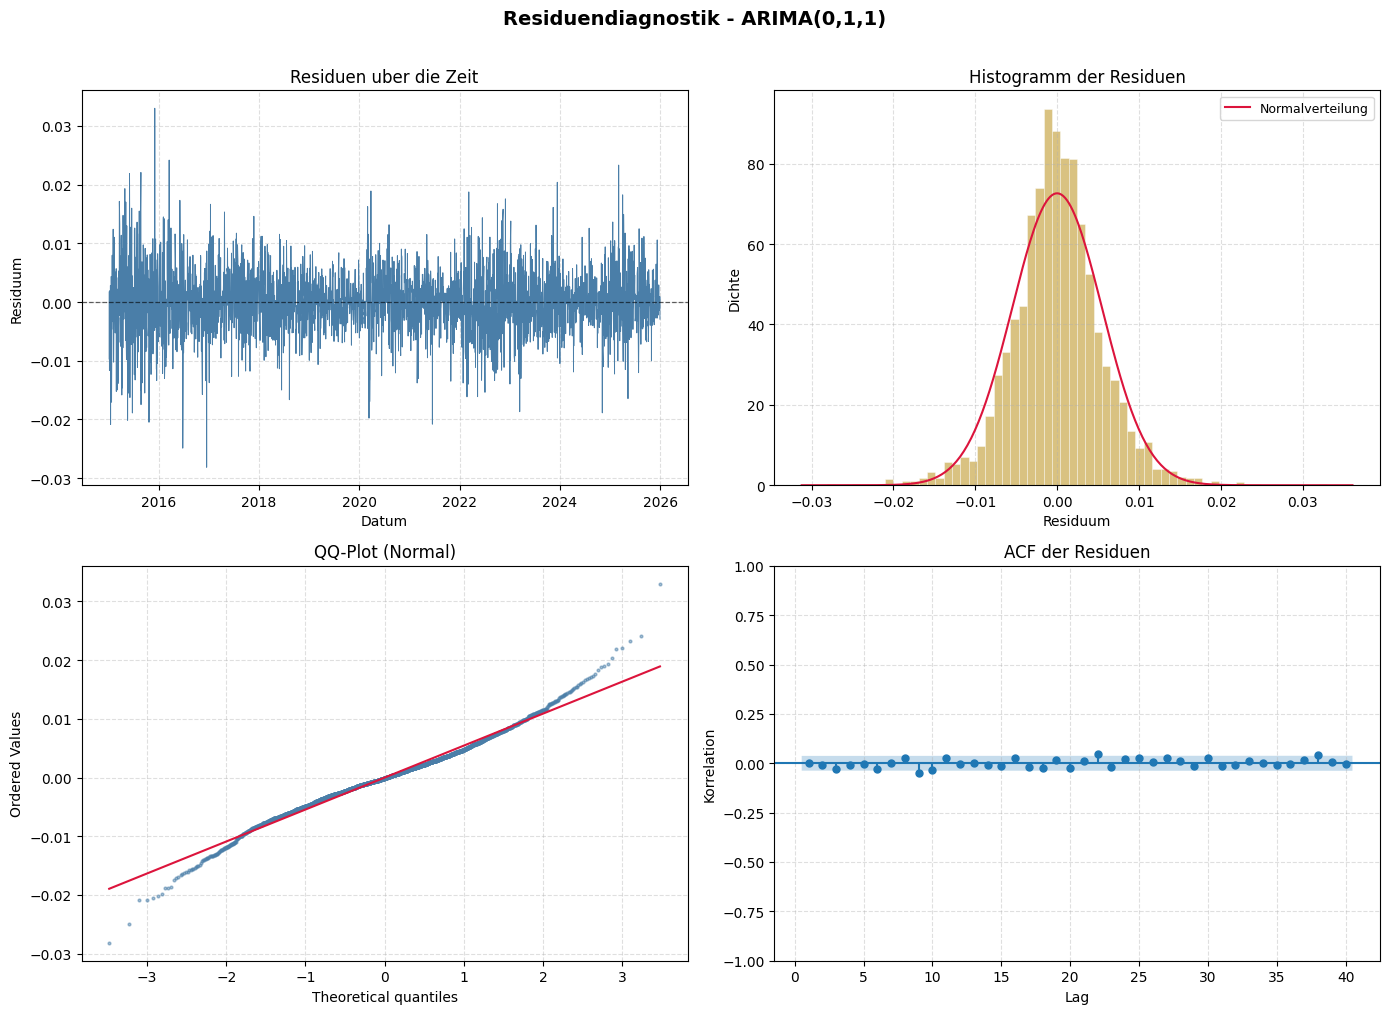

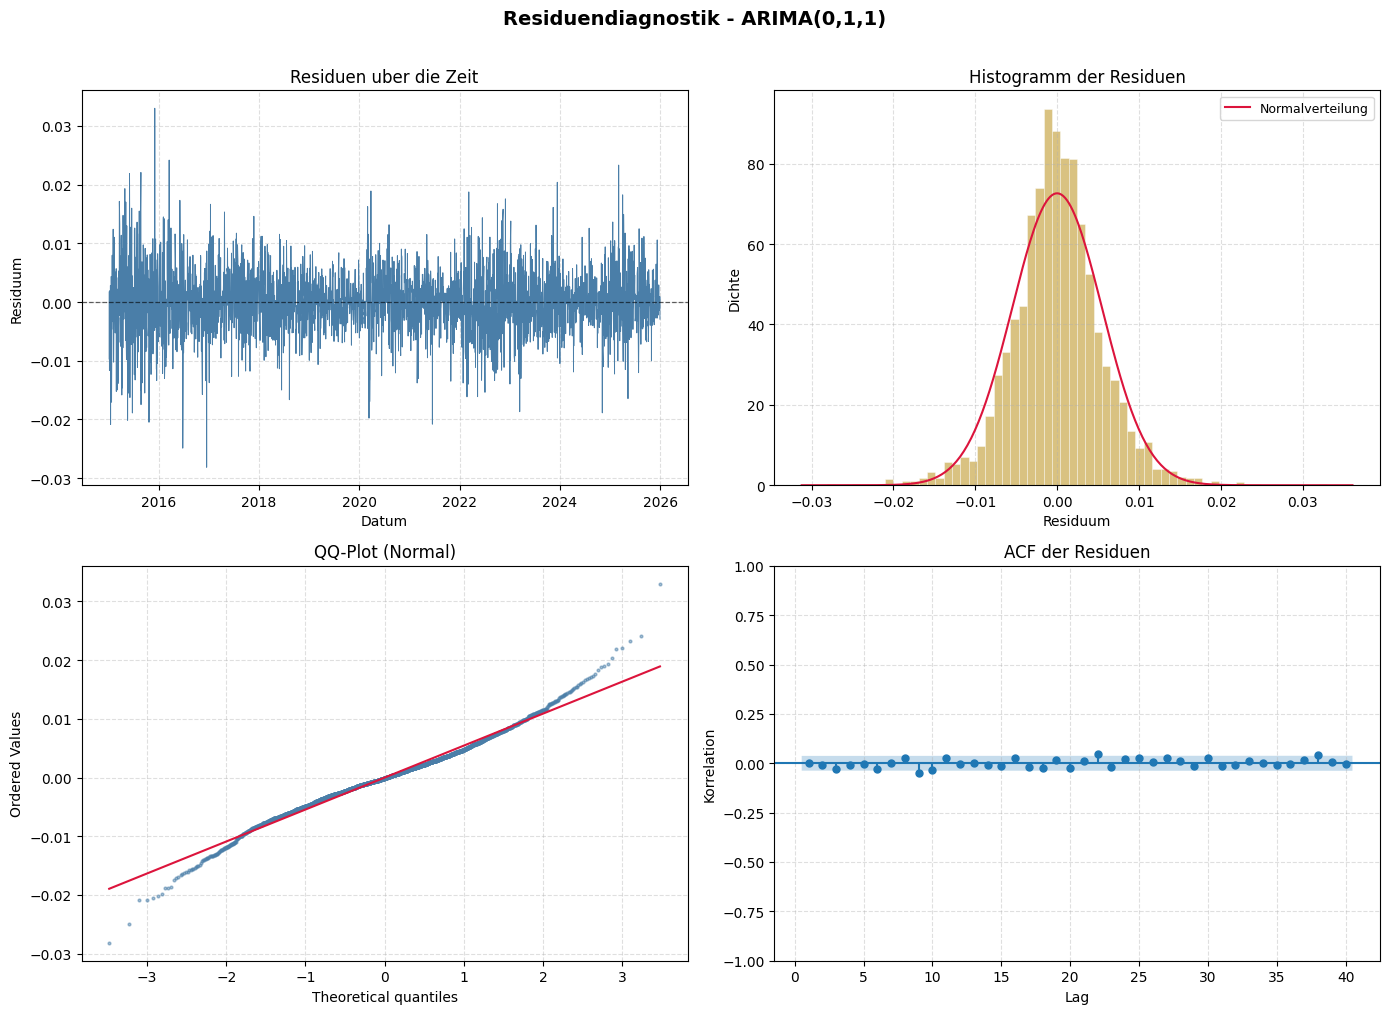

In [15]:
plot_residual_diagnostics(benchmark_model, title="Residuendiagnostik - ARIMA(0,1,1)")

In [16]:
diag_bench = residual_diagnostics(benchmark_model, lags=[10, 20])


Ljung-Box-Test (H0: keine Autokorrelation)
  Lag 10:  Q =  16.8575,  p = 0.0776  (nicht signifikant ✓)
  Lag 20:  Q =  26.2513,  p = 0.1577  (nicht signifikant ✓)

Jarque-Bera-Test (H0: Normalverteilung)
  JB-Statistik : 462.9212
  p-Wert       : 0.0000  → H0 ABGELEHNT (Heavy Tails erwartet)

Deskriptive Statistiken der Residuen
  Mittelwert        :    -0.0000
  Standardabweichung:     0.0055
  Schiefe (Skew)    :     0.0632
  Excess Kurtosis   :     2.0071  (Normalverteilung = 0)



### 6.3 Direkter Vergleich

In [17]:
comparison = pd.DataFrame({
    "ARIMA(0,1,0) Random Walk": [
        diag_main["lb_p_lag10"], diag_main["lb_p_lag20"],
        diag_main["jb_p"], diag_main["mean"], diag_main["std"],
        diag_main["skew"], diag_main["kurtosis"],
    ],
    "ARIMA(0,1,1)": [
        diag_bench["lb_p_lag10"], diag_bench["lb_p_lag20"],
        diag_bench["jb_p"], diag_bench["mean"], diag_bench["std"],
        diag_bench["skew"], diag_bench["kurtosis"],
    ],
}, index=[
    "Ljung-Box p (Lag 10)", "Ljung-Box p (Lag 20)",
    "Jarque-Bera p", "Mittelwert", "Standardabweichung",
    "Schiefe (Skew)", "Excess Kurtosis",
])
display(comparison.round(4))

,"ARIMA(0,1,0) Random Walk","ARIMA(0,1,1)"
Ljung-Box p (Lag 10),0.0524,0.0776
Ljung-Box p (Lag 20),0.1307,0.1577
Jarque-Bera p,0.0000,0.0000
Mittelwert,-0.0000,-0.0000
Standardabweichung,0.0055,0.0055
Schiefe (Skew),0.0668,0.0632
Excess Kurtosis,2.0075,2.0071


### 6.4 Fazit zur Residualdiagnostik

Beide Modelle hinterlassen **weisse Residuen**:

- **Ljung-Box:** p >> 0.05 bei beiden Modellen — keine Autokorrelation ✓
- **Jarque-Bera:** H0 abgelehnt — Heavy Tails sind bei Wechselkursen erwartet und kein Modellfehler ✓
- **Volatilitaetscluster** in den Residuen sichtbar — bekannte ARIMA-Limitation, adressierbar mit GARCH (ausserhalb dieses Rahmens)

Der praktische Unterschied zwischen ARIMA(0,1,0) und ARIMA(0,1,1) ist minimal — das bestaetigt unsere Modellwahl.

---
## Schritt 7: Prognose

**30-Tage-Prognose** mit 95%-Vorhersageintervall.

Da ARIMA(0,1,0) ein Random Walk ist, bleibt der Punktschaetzer konstant — der beste Schaetzer fuer morgen ist der heutige Kurs. Das Vorhersageintervall weitet sich mit dem Zeithorizont auf, da die Unsicherheit mit der Zeit waechst.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


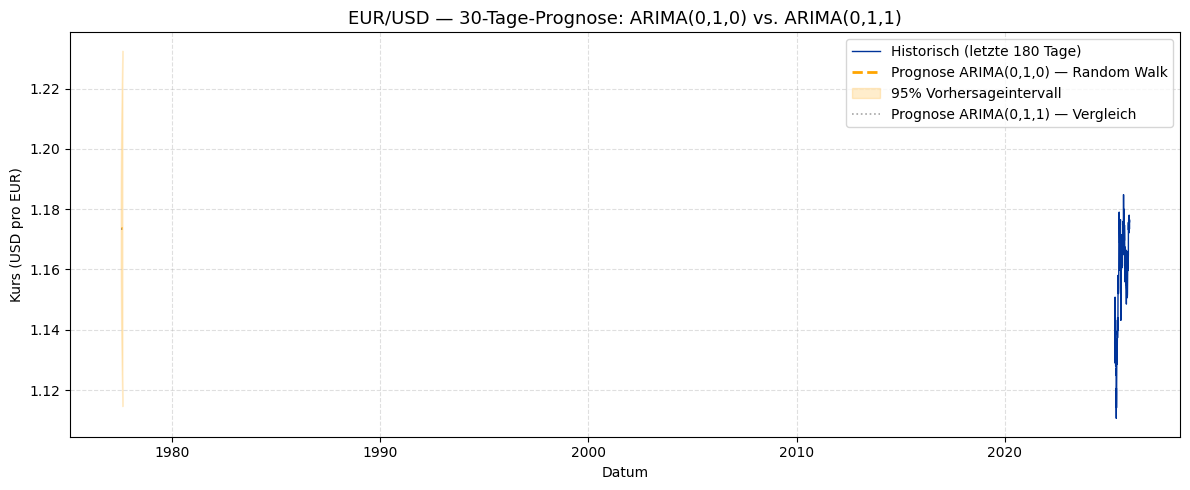


=== Prognosewerte — ARIMA(0,1,0) Random Walk ===
      Prognose  CI_low (95%)  CI_high (95%)
2748    1.1736        1.1628         1.1844
2749    1.1736        1.1584         1.1888
2750    1.1736        1.1550         1.1922
2751    1.1736        1.1521         1.1951
2752    1.1736        1.1495         1.1977
2753    1.1736        1.1472         1.2000
2754    1.1736        1.1451         1.2021
2755    1.1736        1.1432         1.2040
2756    1.1736        1.1413         1.2059
2757    1.1736        1.1396         1.2076


In [18]:
forecast_steps = 30

fc_main  = main_model.get_forecast(steps=forecast_steps)
fc_bench = benchmark_model.get_forecast(steps=forecast_steps)

fc_main_mean  = fc_main.predicted_mean
fc_bench_mean = fc_bench.predicted_mean
fc_main_ci    = fc_main.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(close[-180:].index, close[-180:].values,
        color="#003399", linewidth=1.0, label="Historisch (letzte 180 Tage)")

ax.plot(fc_main_mean.index, fc_main_mean.values,
        color="orange", linewidth=2.0, linestyle="--",
        label="Prognose ARIMA(0,1,0) — Random Walk")
ax.fill_between(fc_main_ci.index,
                fc_main_ci.iloc[:,0], fc_main_ci.iloc[:,1],
                color="orange", alpha=0.2, label="95% Vorhersageintervall")

ax.plot(fc_bench_mean.index, fc_bench_mean.values,
        color="gray", linewidth=1.2, linestyle=":",
        label="Prognose ARIMA(0,1,1) — Vergleich", alpha=0.7)

ax.set_title("EUR/USD — 30-Tage-Prognose: ARIMA(0,1,0) vs. ARIMA(0,1,1)", fontsize=13)
ax.set_xlabel("Datum")
ax.set_ylabel("Kurs (USD pro EUR)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print("\n=== Prognosewerte — ARIMA(0,1,0) Random Walk ===")
print(pd.DataFrame({
    "Prognose": fc_main_mean,
    "CI_low (95%)": fc_main_ci.iloc[:,0],
    "CI_high (95%)": fc_main_ci.iloc[:,1]
}).head(10).round(4))

---
## Zusammenfassung

Die Analyse des EUR/USD-Wechselkurses (2015–2025, Quelle: FRED) ergibt:

| Schritt | Ergebnis |
|---------|----------|
| Stationaritaet | Nicht stationaer (ADF + KPSS) → d = 1 |
| ACF/PACF | Keine signifikanten Lags → Random-Walk-Muster |
| Bestes Modell | **ARIMA(0,1,0)** — AIC und BIC Sieger |
| Residuen | Weisses Rauschen — Ljung-Box p >> 0.05 ✓ |
| Heavy Tails | Jarque-Bera abgelehnt — erwartet bei Wechselkursen ✓ |
| Prognose | Konstanter Punktschaetzer bei ~1.174, Intervall weitet sich auf |

**Fazit:** EUR/USD verhaelt sich wie ein **Random Walk**. Das bestaetigt die Efficient Market Hypothesis (Fama, 1970) fuer Devisenmaerkte — kurzfristige Bewegungen sind mit univariaten ARIMA-Modellen nicht systematisch vorhersagbar. Fuer eine praezisere Modellierung der Volatilitaetscluster waere ein **GARCH-Modell** der naechste Schritt.